# Task 14: Making SIR Stochastic

## Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Defining simulation parameters

In [2]:
N, sim_days = 500, 100
orig_infected = 3
prob_infect = 0.15
contact_with_people = 3
inf_days = 7
beta = prob_infect*contact_with_people
gamma = 1.0 / inf_days

y = [N-orig_infected, orig_infected, 0]
t = [0]

## Implementing the Gillespie algorithm

In [3]:
def sir_gillespie(y, t):
    while t[-1] < sim_days:
        prop_1 = beta * y[-2] * y[-3]/N
        prop_2 = gamma * y[-2]
        prop_tot = sum([prop_1, prop_2])

        tau = np.random.exponential(scale=1/prop_tot)
        prob = np.random.uniform()

        if prob <= prop_1/prop_tot:
            y.extend([y[-3]-1, y[-2]+1, y[-1]])
        else:
            y.extend([y[-3], y[-2]-1, y[-1]+1])
        t.append(t[-1] + tau)

        if y[-2] == 0:
            break
        
    return t, np.reshape(y, (-1, 3))

## Running the simulation and exploring the results

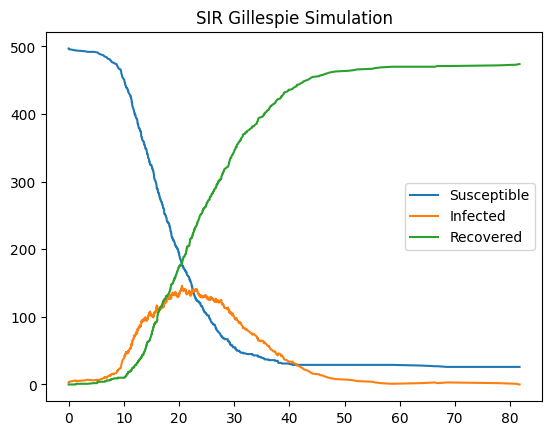

In [4]:
def sim_plot(t, y):
    plt.title("SIR Gillespie Simulation")
    plt.plot(t, y[:, 0], label="Susceptible")
    plt.plot(t, y[:, 1], label="Infected")
    plt.plot(t, y[:, 2], label="Recovered")
    plt.legend()
    plt.show()
    

sim_plot(*sir_gillespie(y, t))